In [1]:
#STEP 1: Install & Imports
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import vgg19
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# load Dataset
import kagglehub

path = kagglehub.dataset_download("adityachandrasekhar/image-super-resolution")

train_dir = os.path.join(path, "dataset", "train")
val_dir = os.path.join(path, "dataset", "val")

100%|██████████| 301M/301M [00:16<00:00, 18.8MB/s]

Extracting files...


In [3]:
# Transform
low_res_size = 128
high_res_size = 256

transform_low = transforms.Compose([
    transforms.Resize((low_res_size, low_res_size)),
    transforms.ToTensor()
])

transform_high = transforms.Compose([
    transforms.Resize((high_res_size, high_res_size)),
    transforms.ToTensor()
])

In [4]:
## Dataset Class
class ImageDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.low_files = os.listdir(os.path.join(root_dir, "low_res"))
        self.high_files = os.listdir(os.path.join(root_dir, "high_res"))

    def __len__(self):
        return len(self.low_files)

    def __getitem__(self, idx):
        lr = Image.open(os.path.join(self.root_dir, "low_res", self.low_files[idx])).convert("RGB")
        hr = Image.open(os.path.join(self.root_dir, "high_res", self.high_files[idx])).convert("RGB")

        lr = transform_low(lr)
        hr = transform_high(hr)

        return lr, hr

In [5]:
## Dataloader
train_loader = DataLoader(ImageDataset(train_dir), batch_size=16, shuffle=True)
val_loader = DataLoader(ImageDataset(val_dir), batch_size=1, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
##EDSR Model
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, 1, 1)
        )

    def forward(self, x):
        return x + self.block(x)

class EDSR(nn.Module):
    def __init__(self, channels=64, num_blocks=16):
        super().__init__()
        self.input = nn.Conv2d(3, channels, 3, 1, 1)
        self.res = nn.Sequential(*[ResidualBlock(channels) for _ in range(num_blocks)])
        self.conv = nn.Conv2d(channels, channels, 3, 1, 1)
        self.up = nn.Sequential(
            nn.Conv2d(channels, channels * 4, 3, 1, 1),
            nn.PixelShuffle(2)
        )
        self.output = nn.Conv2d(channels, 3, 3, 1, 1)

    def forward(self, x):
        x1 = self.input(x)
        x2 = self.res(x1)
        x3 = self.conv(x2) + x1
        x4 = self.up(x3)
        return self.output(x4)

## Loss Functions (NOVELTY 🔥)

In [ ]:
## Pixel Loss
pixel_loss_fn = nn.L1Loss()


In [ ]:
## Perceptual Loss
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = vgg19(pretrained=True).features[:16].eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        return F.mse_loss(self.vgg(sr), self.vgg(hr))

In [ ]:
##Edge Loss
def edge_loss(sr, hr):
    sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(sr.device)
    sobel_y = sobel_x.permute(0,1,3,2)

    sr_gray = sr.mean(dim=1, keepdim=True)
    hr_gray = hr.mean(dim=1, keepdim=True)

    sr_edge = F.conv2d(sr_gray, sobel_x, padding=1) + F.conv2d(sr_gray, sobel_y, padding=1)
    hr_edge = F.conv2d(hr_gray, sobel_x, padding=1) + F.conv2d(hr_gray, sobel_y, padding=1)

    return F.l1_loss(sr_edge, hr_edge)

In [ ]:
## Initialize model
model = EDSR().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
perceptual_loss_fn = VGGPerceptualLoss().to(device)

lambda_pixel = 1.0
lambda_perceptual = 0.01
lambda_edge = 0.1

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 172MB/s]


In [ ]:
total_losses = []
pixel_losses = []
perceptual_losses = []
edge_losses = []

In [ ]:
# Training Loop
epochs = 10

for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader)

    for lr, hr in loop:
        lr, hr = lr.to(device), hr.to(device)

        sr = model(lr)

        pixel_loss = pixel_loss_fn(sr, hr)
        perceptual_loss = perceptual_loss_fn(sr, hr)
        edge_l = edge_loss(sr, hr)

        loss = (lambda_pixel * pixel_loss +
                lambda_perceptual * perceptual_loss +
                lambda_edge * edge_l)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch {epoch}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch} Loss: {loss.item()}")

Epoch 0: 100%|██████████| 43/43 [00:40<00:00,  1.07it/s, loss=0.0877]


Epoch 0 Loss: 0.08765687793493271


Epoch 1: 100%|██████████| 43/43 [00:38<00:00,  1.11it/s, loss=0.0744]


Epoch 1 Loss: 0.07443928718566895


Epoch 2: 100%|██████████| 43/43 [00:40<00:00,  1.06it/s, loss=0.0644]


...

Epoch 7 Loss: 0.03873329609632492


Epoch 8: 100%|██████████| 43/43 [00:40<00:00,  1.07it/s, loss=0.0518]


Epoch 8 Loss: 0.05175222083926201


Epoch 9: 100%|██████████| 43/43 [00:40<00:00,  1.07it/s, loss=0.0335]

Epoch 9 Loss: 0.03346472606062889


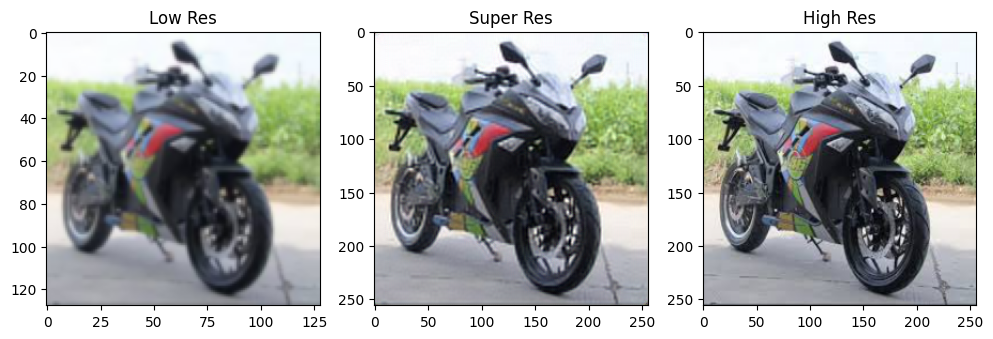

In [ ]:
## Visulaization
def show_results(model):
    model.eval()
    lr, hr = next(iter(val_loader))

    with torch.no_grad():
        sr = model(lr.to(device)).cpu()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(lr[0].permute(1,2,0))
    plt.title("Low Res")

    plt.subplot(1,3,2)
    plt.imshow(sr[0].permute(1,2,0))
    plt.title("Super Res")

    plt.subplot(1,3,3)
    plt.imshow(hr[0].permute(1,2,0))
    plt.title("High Res")

    plt.show()

show_results(model)

In [ ]:
## PSNR & SSIM
def calculate_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

def calculate_ssim(sr, hr):
    return torch.mean((2*sr*hr+1e-8)/(sr**2+hr**2+1e-8))

psnr_list = []
ssim_list = []

model.eval()
for lr, hr in val_loader:
    lr, hr = lr.to(device), hr.to(device)

    with torch.no_grad():
        sr = model(lr)

    psnr_list.append(calculate_psnr(sr, hr).item())
    ssim_list.append(calculate_ssim(sr, hr).item())

print("Average PSNR:", np.mean(psnr_list))
print("Average SSIM:", np.mean(ssim_list))

Average PSNR: 29.57494458591237
Average SSIM: 0.9592862748924423
